In [55]:
from src.core import NoisyFloat
from src.noise import NormalNoiseSource

import src.visual as visual

## Noisy numbers

Suppose we have two numbers `x` and `y`.

In [56]:
x = 8.0
y = 13.0

We can do arithmetic on them. Because we are certain about the values of the numbers, we are certain about the result of the arithmetic.

In [57]:
z = x + y
z

21.0

But suppose we aren't certain. Suppose we don't know that `x` is 8 and `y` is 13. Instead we have _observations_ of `x` and `y`, but we understand that those observations aren't quite right: there's some _noise_ involved. Suppose also we know that noise is drawn **separately** for `x` and `y` from a Normal distribution with $\mu = 0.0$ and $\sigma = 7.0$.

Then we can model `x` and `y` like this.

In [58]:
x = NoisyFloat.draw(true_value=8.0, noise_source=NormalNoiseSource(loc=0.0, scale=7.0))
y = NoisyFloat.draw(true_value=13.0, noise_source=NormalNoiseSource(loc=0.0, scale=7.0))

This is what `NoisyFloat` does: it pairs a noisy observation with our belief about what the true value actually is, in the form of a _posterior probability distribution_ - in this case, it's a Normal probability distribution centered on the measured value.

The observation part is stored inside the `NoisyFloat` as a floating point number. We can access it by converting the `NoisyFloat` to a `float` like this.

In [59]:
float(x)

21.504631343003528

In [60]:
float(y)

5.454359198837732

Notice the observations are not 8 and 13 anymore. In fact, 8 and 13 exist nowhere in `x` or `y` now, and they are not recoverable!

The posteriors are represented inside the `NoisyFloat` too, symbolically, in a way that is difficult to interact with manually. A good way for us to get a sense for the posterior is by plotting it. We can even plot the posteriors of `x` and `y` together.

{'ax': <Axes: title={'center': 'Posterior Densities of Composed Expressions'}, xlabel='Expression value', ylabel='Posterior density'>,
 'curves': [{'noisy_value': ~21.504631343003528,
   'x': array([ 1.51344413,  1.59356913,  1.67369413,  1.75381913,  1.83394413,
           1.91406912,  1.99419412,  2.07431912,  2.15444412,  2.23456912,
           2.31469412,  2.39481912,  2.47494412,  2.55506912,  2.63519411,
           2.71531911,  2.79544411,  2.87556911,  2.95569411,  3.03581911,
           3.11594411,  3.19606911,  3.2761941 ,  3.3563191 ,  3.4364441 ,
           3.5165691 ,  3.5966941 ,  3.6768191 ,  3.7569441 ,  3.8370691 ,
           3.9171941 ,  3.99731909,  4.07744409,  4.15756909,  4.23769409,
           4.31781909,  4.39794409,  4.47806909,  4.55819409,  4.63831909,
           4.71844408,  4.79856908,  4.87869408,  4.95881908,  5.03894408,
           5.11906908,  5.19919408,  5.27931908,  5.35944407,  5.43956907,
           5.51969407,  5.59981907,  5.67994407,  5.76006907,

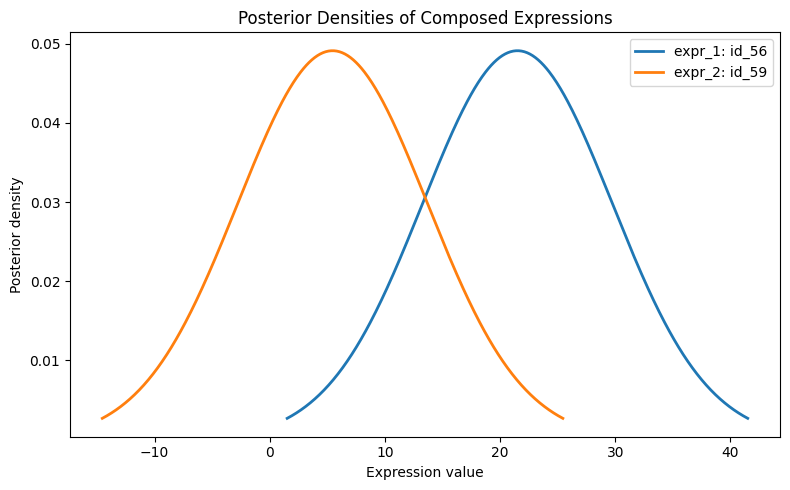

In [61]:
visual.plot_posterior(x, y)

What happens if we add `x` and `y` now?

In [62]:
z = x + y
z

~26.95899054184126

We get a new `NoisyFloat` whose _observation_ is the sum of the observations of `x` and `y` and whose posterior takes into account the posteriors of `x` and `y`. Notice when we plot all three together how `z` is expected to be higher than both `x` and `y` because it is their sum, but its tails are thicker. We can less certain about what `z` actually is because it _combines_ our uncertainty about `x` with our uncertainty about `y`.

{'ax': <Axes: title={'center': 'Posterior Densities of Composed Expressions'}, xlabel='Expression value', ylabel='Posterior density'>,
 'curves': [{'noisy_value': ~21.504631343003528,
   'x': array([ 1.51344413,  1.59356913,  1.67369413,  1.75381913,  1.83394413,
           1.91406912,  1.99419412,  2.07431912,  2.15444412,  2.23456912,
           2.31469412,  2.39481912,  2.47494412,  2.55506912,  2.63519411,
           2.71531911,  2.79544411,  2.87556911,  2.95569411,  3.03581911,
           3.11594411,  3.19606911,  3.2761941 ,  3.3563191 ,  3.4364441 ,
           3.5165691 ,  3.5966941 ,  3.6768191 ,  3.7569441 ,  3.8370691 ,
           3.9171941 ,  3.99731909,  4.07744409,  4.15756909,  4.23769409,
           4.31781909,  4.39794409,  4.47806909,  4.55819409,  4.63831909,
           4.71844408,  4.79856908,  4.87869408,  4.95881908,  5.03894408,
           5.11906908,  5.19919408,  5.27931908,  5.35944407,  5.43956907,
           5.51969407,  5.59981907,  5.67994407,  5.76006907,

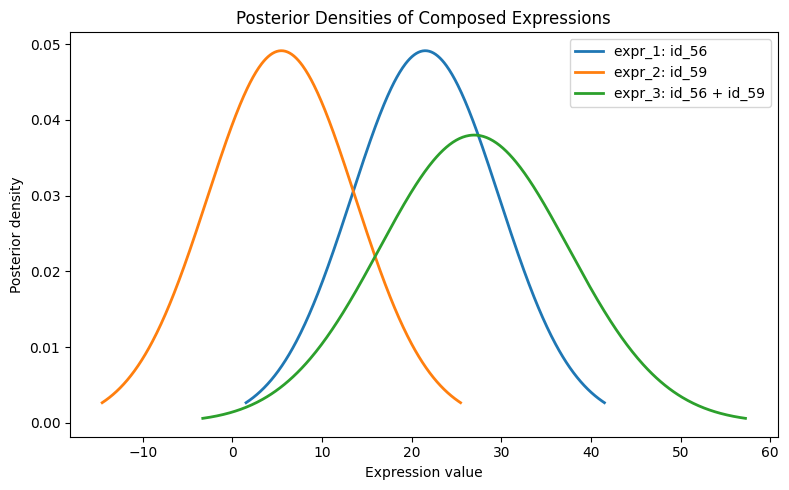

In [63]:
visual.plot_posterior(x, y, z)

Most common arithmetic operations are supported. In this way, the library pairs observations and posteriors together, and propagates them in tandem through arithmetic operations.

## Interpreting posteriors

The posterior tells the "whole story" about what we should believe about the true value associated with an observation, but standard metrics can be derived from it that are sometimes easier to work with. It all starts with sampling the posterior.

In [64]:
batch = z.sample(n=1000)

Now we have `batch` which is a `SampleBatch` object. `SampleBatch` just wraps a NumPy array, so we can always take `batch.draws` and do whatever we want with that.

There are some convenience methods on `batch` though. Most notably there is a way to get the _credible interval_ for `z`. A credible interval is similar to a confidence interval, but for Bayesian statistics.

In [65]:
batch.credible_interval(0.95)

array([ 8.44099918, 46.35150098])

As an aside... for the Normal distributions we've been working with, it's technically possible to get these metrics without sampling: there are nice analytic solutions. However since the library supports more than just simple Normal distributions, it opts for the more universal sampling approach.

## Noisy booleans

Suppose we want to _compare_ `x` and `y`. Maybe we're curious if `y` is really larger. If we notice how the plots of their posteriors that we created earlier have overlap, we will know there is a chance that the true value of `x` is actually larger than that of `y`, even though we have observations that (probably) suggest otherwise.

In [66]:
g = y > x
g

~False

The result of the comparison is `g`, a `NoisyBool`. `NoisyBool` is very similar to `NoisyFloat` in that it pairs a noisy observation - a `bool` in this case - with a posterior.

Sampling the posterior gives Trues and Falses, which we can see if we look at the first few elements of the resulting sample batch.

In [67]:
batch = g.sample(n=1000)
batch.draws[:5]

array([False, False,  True, False, False])

We can sum the batch elements together and divide by the number of elements to get the probability that `y > x`.

(TODO) It probably makes sense to provide a more idiomatic way to do this soon.

In [68]:
sum(batch.draws) / len(batch.draws)

np.float64(0.064)

What about if we want to know the probability that `z` is between 22.0 and 26.0? We can use boolean connectives like `&`, `|`, and `not`.

In [ ]:
g = (z >= 22.0) & (z <= 26.0)
g

Notice how we're mixing regular numbers in with the the `NoisyFloat` object `z` here. This is usually okay because the library can _lift_ regular values into noisy values as needed. But we can also lift explicitly, creating noisy values that are 22.0 or 26.0 with complete certainty.

In [ ]:
g = (z >= NoisyFloat.lift(22.0)) & (z <= NoisyFloat.lift(26.0))
g

And exactly as before, we can sample the posterior of `g` to estimate the probability that `g` is True.

In [71]:
batch = g.sample(n=1000)
sum(batch.draws) / len(batch.draws)

np.float64(0.151)

## Dependence and independence

asdf

## Contingency tables

asdf

## Differential privacy

asdf

## Sharing noisy systems


asdf